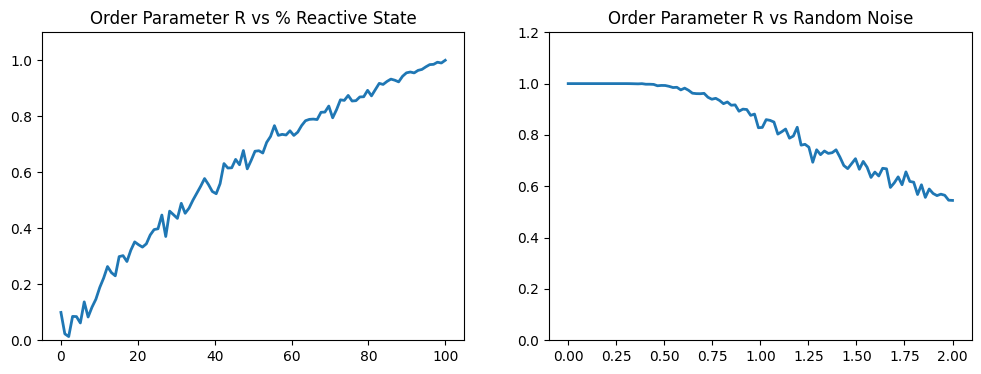

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_order_parameter():
    # Simulación para R vs % de multitud reactiva
    n_agents = 1000
    r_values = []
    percents = np.linspace(0, 1, 100)
    
    for p in percents:
        n_reactive = int(p * n_agents)
        # Agentes reactivos: misma dirección (1.0)
        # Agentes racionales: dirección aleatoria
        actions = np.concatenate([
            np.ones(n_reactive), 
            np.random.uniform(-1, 1, n_agents - n_reactive)
        ])
        R = np.abs(np.sum(actions)) / np.sum(np.abs(actions))
        r_values.append(R)

    # Simulación para R vs Ruido aleatorio
    noise_levels = np.linspace(0, 2, 100)
    r_noise = []
    for e in noise_levels:
        # Acciones con ruido añadido
        actions = 1.0 + np.random.normal(0, e, n_agents)
        R = np.abs(np.sum(actions)) / np.sum(np.abs(actions))
        r_noise.append(R)

    return percents, r_values, noise_levels, r_noise

# Plotting Image 1
p, rv, n, rn = calculate_order_parameter()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(p*100, rv, linewidth=2)
ax[0].set_title("Order Parameter R vs % Reactive State")
ax[0].set_ylim(0, 1.1)

ax[1].plot(n, rn, linewidth=2)
ax[1].set_title("Order Parameter R vs Random Noise")
ax[1].set_ylim(0, 1.2)
plt.show()

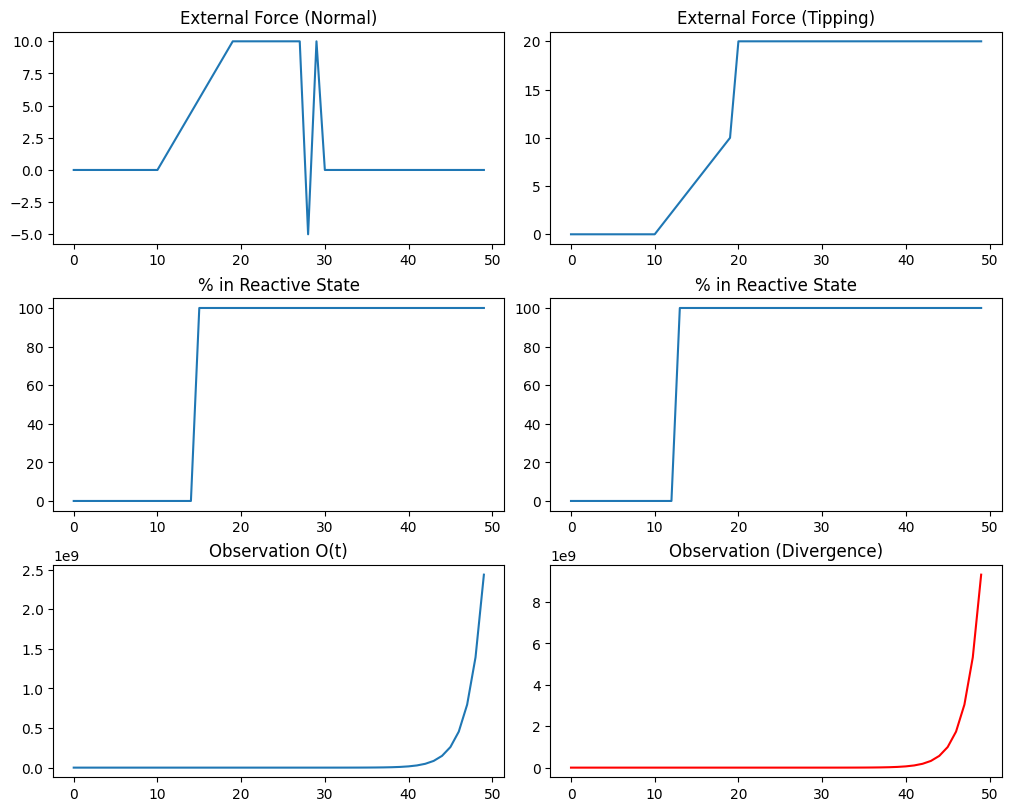

In [2]:
def simulate_bubble(tipping_point=False):
    steps = 50
    N = 100
    A = 0.012 if tipping_point else 0.008  # Impacto de los agentes
    C = 1.0   # Sensibilidad a fuerza externa
    
    # Parámetros de estado reactivo
    B_low = 0.5   # Rational
    B_high = 90.0 if tipping_point else 40.0 # Reactive
    
    E = np.zeros(steps)
    E[10:20] = np.linspace(0, 10, 10) # Fuerza externa subiendo
    if not tipping_point:
        E[20:30] = 10
        E[28] = -5 # Caída brusca para ver respuesta
    else:
        E[20:] = 20

    O = np.zeros(steps)
    pct_reactive = np.zeros(steps)
    
    for t in range(1, steps):
        dE = E[t] - E[t-1]
        
        # Umbral para volverse reactivo (basado en cambio en O)
        is_reactive = np.abs(O[t-1]) > 5
        B = np.where(is_reactive, B_high, B_low)
        pct_reactive[t] = np.mean(is_reactive)
        
        # dO = sum(A * (C*dE + B*dO_prev)) -> Simplificación del loop
        # dO = (A*N*C*dE) / (1 - A*N*B_mean)
        B_mean = np.mean(B)
        feedback = A * N * B_mean
        
        if feedback >= 1.0: # Punto de inestabilidad
            dO = (A * N * C * dE) + 0.5 * O[t-1] 
            O[t] = O[t-1] + dO * 1.5 # Crecimiento exponencial
        else:
            dO = (A * N * C * dE) / (1 - feedback)
            O[t] = O[t-1] + dO
            
    return E, pct_reactive, O

# Generar datos
E1, P1, O1 = simulate_bubble(tipping_point=False)
E2, P2, O2 = simulate_bubble(tipping_point=True)

# Crear la cuadrícula de 3x2 como en la imagen 3
fig, axes = plt.subplots(3, 2, figsize=(10, 8), constrained_layout=True)

# Column 1: Normal Simulation
axes[0,0].plot(E1); axes[0,0].set_title("External Force (Normal)")
axes[1,0].plot(P1*100); axes[1,0].set_title("% in Reactive State")
axes[2,0].plot(O1); axes[2,0].set_title("Observation O(t)")

# Column 2: Tipping Point
axes[0,1].plot(E2); axes[0,1].set_title("External Force (Tipping)")
axes[1,1].plot(P2*100); axes[1,1].set_title("% in Reactive State")
axes[2,1].plot(O2, color='red'); axes[2,1].set_title("Observation (Divergence)")

plt.show()